In [1]:
import torch
import random
import numpy as np

# --------------------------------------------------
# Reproducibility Seed
# --------------------------------------------------

seed = 42

random.seed(seed)
np.random.seed(seed)

torch.manual_seed(seed)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

print("Random seed set for reproducibility.")

Random seed set for reproducibility.


# *Loading Data*

In [2]:
train = "/kaggle/input/datasets/vaishnavitripathi217/dataset-face-forensic/final_deepfake_project_dataset/train"
test = "/kaggle/input/datasets/vaishnavitripathi217/dataset-face-forensic/final_deepfake_project_dataset/test"
validation = "/kaggle/input/datasets/vaishnavitripathi217/dataset-face-forensic/final_deepfake_project_dataset/validation"

In [3]:
import os

def load_images_from_dirs(dir_list):
    all_images = []

    for directory in dir_list:
        for img in os.listdir(directory):
            img_path = os.path.join(directory, img)

            if os.path.isfile(img_path):
                all_images.append(img_path)

    return all_images

In [4]:
test_fake_dirs = [
    "/kaggle/input/datasets/vaishnavitripathi217/dataset-face-forensic/final_deepfake_project_dataset/test/Deepfakes",
    "/kaggle/input/datasets/vaishnavitripathi217/dataset-face-forensic/final_deepfake_project_dataset/test/Face2Face",
    "/kaggle/input/datasets/vaishnavitripathi217/dataset-face-forensic/final_deepfake_project_dataset/test/FaceShifter",
    "/kaggle/input/datasets/vaishnavitripathi217/dataset-face-forensic/final_deepfake_project_dataset/test/FaceSwap",
    "/kaggle/input/datasets/vaishnavitripathi217/dataset-face-forensic/final_deepfake_project_dataset/test/NeuralTextures"
]

test_real_dirs = [
    "/kaggle/input/datasets/vaishnavitripathi217/dataset-face-forensic/final_deepfake_project_dataset/test/real"
]

test_fake = load_images_from_dirs(test_fake_dirs)
test_real = load_images_from_dirs(test_real_dirs)

print(len(test_fake))
print(len(test_real))

2250
2250


In [5]:
train_fake_dirs = [
    "/kaggle/input/datasets/vaishnavitripathi217/dataset-face-forensic/final_deepfake_project_dataset/train/Deepfakes",
    "/kaggle/input/datasets/vaishnavitripathi217/dataset-face-forensic/final_deepfake_project_dataset/train/Face2Face",
    "/kaggle/input/datasets/vaishnavitripathi217/dataset-face-forensic/final_deepfake_project_dataset/train/FaceShifter",
    "/kaggle/input/datasets/vaishnavitripathi217/dataset-face-forensic/final_deepfake_project_dataset/train/FaceSwap",
    "/kaggle/input/datasets/vaishnavitripathi217/dataset-face-forensic/final_deepfake_project_dataset/train/NeuralTextures"
]

train_real_dirs = [
    "/kaggle/input/datasets/vaishnavitripathi217/dataset-face-forensic/final_deepfake_project_dataset/train/real"
]

train_fake = load_images_from_dirs(train_fake_dirs)
train_real = load_images_from_dirs(train_real_dirs)

print(len(train_fake))
print(len(train_real))

10500
10500


In [6]:
validation_fake_dirs = [
    "/kaggle/input/datasets/vaishnavitripathi217/dataset-face-forensic/final_deepfake_project_dataset/validation/Deepfakes",
    "/kaggle/input/datasets/vaishnavitripathi217/dataset-face-forensic/final_deepfake_project_dataset/validation/Face2Face",
    "/kaggle/input/datasets/vaishnavitripathi217/dataset-face-forensic/final_deepfake_project_dataset/validation/FaceShifter",
    "/kaggle/input/datasets/vaishnavitripathi217/dataset-face-forensic/final_deepfake_project_dataset/validation/FaceSwap",
    "/kaggle/input/datasets/vaishnavitripathi217/dataset-face-forensic/final_deepfake_project_dataset/validation/NeuralTextures"
]

validation_real_dirs = [
    "/kaggle/input/datasets/vaishnavitripathi217/dataset-face-forensic/final_deepfake_project_dataset/validation/real"
]

validation_fake = load_images_from_dirs(validation_fake_dirs)
validation_real = load_images_from_dirs(validation_real_dirs)

print(len(validation_fake))
print(len(validation_real))

2250
2250


# Data loaders 


In [7]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import time
import copy

class DeepfakeDataset(Dataset):
    def __init__(self, fake_paths, real_paths, transform=None):
        
        self.image_paths = fake_paths + real_paths
        self.labels = [1] * len(fake_paths) + [0] * len(real_paths)
        
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        
        img_path = self.image_paths[idx]
        label = self.labels[idx]

        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label

In [8]:
# ============================================================
# CUSTOM AUGMENTATION CLASSES
# Defined here so both Augmented EfficientNet and
# Augmented XceptionNet sections can use them.
# ============================================================

import random
import torch

class SimulateJPEGCompression(object):
    def __init__(self, quality_range=(80, 95), p=0.15):
        self.quality_range = quality_range
        self.p = p

    def __call__(self, tensor):
        if random.random() < self.p:
            quality = random.randint(self.quality_range[0], self.quality_range[1])
            tensor = (torch.round(tensor * quality) / quality)
        return tensor


class AddGaussianNoise(object):
    def __init__(self, mean=0.0, std=0.01, p=0.1):
        self.mean = mean
        self.std = std
        self.p = p

    def __call__(self, tensor):
        if random.random() < self.p:
            noise = torch.randn_like(tensor) * self.std + self.mean
            tensor = tensor + noise
            tensor = torch.clamp(tensor, 0., 1.)
        return tensor

print("Custom augmentation classes defined: SimulateJPEGCompression, AddGaussianNoise")


Custom augmentation classes defined: SimulateJPEGCompression, AddGaussianNoise


# *Train Model Function*

In [9]:
# ============================================================
# TRAINING FUNCTION
# ============================================================

def train_model(
    model,
    criterion,
    optimizer,
    train_loader,
    val_loader,
    num_epochs=25,
    patience=5,
    save_path="best_model.pth"
):

    since = time.time()

    # --------------------------------------------------------
    # AUTOMATIC DEVICE DETECTION
    # --------------------------------------------------------

    device = torch.device(
        "cuda" if torch.cuda.is_available() else "cpu"
    )

    model = model.to(device)

    # --------------------------------------------------------
    # BEST MODEL TRACKING
    # --------------------------------------------------------

    best_model_wts = copy.deepcopy(model.state_dict())

    best_acc = 0.0

    epochs_no_improve = 0

    early_stop = False

    # --------------------------------------------------------
    # HISTORY TRACKING
    # --------------------------------------------------------

    history = {
        'train_loss': [],
        'train_acc': [],
        'val_loss': [],
        'val_acc': []
    }

    # ========================================================
    # EPOCH LOOP
    # ========================================================

    for epoch in range(num_epochs):

        print(f'Epoch {epoch+1}/{num_epochs}')
        print('-' * 10)

        # ====================================================
        # TRAIN + VALIDATION PHASES
        # ====================================================

        for phase in ['train', 'val']:

            if phase == 'train':

                model.train()

                dataloader = train_loader

            else:

                model.eval()

                dataloader = val_loader

            running_loss = 0.0

            running_corrects = 0

            # =================================================
            # ITERATE OVER DATA
            # =================================================

            for inputs, labels in dataloader:

                inputs = inputs.to(device)

                labels = labels.to(device)

                # --------------------------------------------
                # ZERO GRADIENTS
                # --------------------------------------------

                optimizer.zero_grad()

                # --------------------------------------------
                # FORWARD PASS
                # --------------------------------------------

                with torch.set_grad_enabled(
                    phase == 'train'
                ):

                    outputs = model(inputs)

                    _, preds = torch.max(
                        outputs,
                        1
                    )

                    loss = criterion(
                        outputs,
                        labels
                    )

                    # ----------------------------------------
                    # BACKWARD + OPTIMIZE
                    # ----------------------------------------

                    if phase == 'train':

                        loss.backward()

                        optimizer.step()

                # --------------------------------------------
                # STATISTICS
                # --------------------------------------------

                running_loss += (
                    loss.item() * inputs.size(0)
                )

                running_corrects += torch.sum(
                    preds == labels.data
                )

            # =================================================
            # EPOCH METRICS
            # =================================================

            epoch_loss = (
                running_loss / len(dataloader.dataset)
            )

            epoch_acc = (
                running_corrects.double()
                / len(dataloader.dataset)
            )

            print(
                f'{phase} Loss: '
                f'{epoch_loss:.4f} '
                f'Acc: {epoch_acc:.4f}'
            )

            history[f'{phase}_loss'].append(
                epoch_loss
            )

            history[f'{phase}_acc'].append(
                epoch_acc.item()
            )

            # =================================================
            # SAVE BEST MODEL
            # =================================================

            if phase == 'val':

                if epoch_acc > best_acc:

                    best_acc = epoch_acc

                    best_model_wts = copy.deepcopy(
                        model.state_dict()
                    )

                    epochs_no_improve = 0

                    # ----------------------------------------
                    # SAVE BEST MODEL
                    # ----------------------------------------

                    torch.save(
                        model.state_dict(),
                        save_path
                    )

                    print(
                        "Best model saved."
                    )

                else:

                    epochs_no_improve += 1

        # ====================================================
        # EARLY STOPPING
        # ====================================================

        if epochs_no_improve == patience:

            print(
                f'Early stopping triggered '
                f'after {patience} epochs '
                f'with no improvement '
                f'in validation accuracy.'
            )

            early_stop = True

            break

        # ====================================================
        # CLEAR CUDA CACHE
        # ====================================================

        torch.cuda.empty_cache()

    # ========================================================
    # TRAINING COMPLETE
    # ========================================================

    time_elapsed = time.time() - since

    print(
        f'Training complete in '
        f'{time_elapsed // 60:.0f}m '
        f'{time_elapsed % 60:.0f}s'
    )

    print(f'Best val Acc: {best_acc:.4f}')

    # ========================================================
    # LOAD BEST MODEL WEIGHTS
    # ========================================================

    model.load_state_dict(best_model_wts)

    return model, history

print(
    "Training function `train_model` defined. "
    "You can now call it normally."
)

Training function `train_model` defined. You can now call it normally.


In [10]:
# ============================================================
# GLOBAL CONFIG  (used by all ViT sections)
# ============================================================
import torch

BATCH_SIZE = 32
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

print(f"Batch size : {BATCH_SIZE}")
print(f"Device     : {device}")


Batch size : 32
Device     : cuda:0


# Vision Transformer — ViT-B/16 (Baseline Model 1)

In [11]:
# ============================================================
# ViT-B/16  DATA LOADERS
# Native resolution: 224×224
# ============================================================
from torch.utils.data import DataLoader
from torchvision import transforms

IMG_SIZE_VIT = 224

train_transform_vit = transforms.Compose([
    transforms.Resize((IMG_SIZE_VIT, IMG_SIZE_VIT)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(
        brightness=0.08, contrast=0.08,
        saturation=0.05, hue=0.02
    ),
    transforms.RandomApply([transforms.GaussianBlur(kernel_size=3)], p=0.1),
    transforms.ToTensor(),
    AddGaussianNoise(std=0.01, p=0.1),
    SimulateJPEGCompression(quality_range=(80, 95), p=0.15),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_test_transform_vit = transforms.Compose([
    transforms.Resize((IMG_SIZE_VIT, IMG_SIZE_VIT)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

train_dataset_vit_b16 = DeepfakeDataset(train_fake, train_real,
                                         transform=train_transform_vit)
val_dataset_vit_b16   = DeepfakeDataset(validation_fake, validation_real,
                                         transform=val_test_transform_vit)
test_dataset_vit_b16  = DeepfakeDataset(test_fake, test_real,
                                         transform=val_test_transform_vit)

train_loader_vit_b16 = DataLoader(train_dataset_vit_b16, batch_size=BATCH_SIZE,
                                   shuffle=True,  num_workers=2)
val_loader_vit_b16   = DataLoader(val_dataset_vit_b16,   batch_size=BATCH_SIZE,
                                   shuffle=False, num_workers=2)
test_loader_vit_b16  = DataLoader(test_dataset_vit_b16,  batch_size=BATCH_SIZE,
                                   shuffle=False, num_workers=2)

print(f"ViT-B/16 loaders ready — image size: {IMG_SIZE_VIT}×{IMG_SIZE_VIT}")
print(f"  Train: {len(train_dataset_vit_b16)} | Val: {len(val_dataset_vit_b16)} | Test: {len(test_dataset_vit_b16)}")


ViT-B/16 loaders ready — image size: 224×224
  Train: 21000 | Val: 4500 | Test: 4500


In [12]:
import torchvision.models as models
import torch.nn as nn
import torch.optim as optim

# ============================================================
# ViT-B/16 MODEL SETUP
# patch_size=16, hidden_dim=768, heads=12, layers=12
# ============================================================

model_vit_b16 = models.vit_b_16(
    weights=models.ViT_B_16_Weights.DEFAULT
)

# --- Freeze entire backbone ---
for param in model_vit_b16.parameters():
    param.requires_grad = False

print("All ViT-B/16 layers frozen.")

# --- Unfreeze last 3 encoder blocks (out of 12) ---
for block in model_vit_b16.encoder.layers[-3:]:
    for param in block.parameters():
        param.requires_grad = True

print("Last 3 transformer encoder blocks unfrozen.")

# --- Replace classification head ---
# ViT uses model.heads.head as the final Linear layer
in_features_vit_b16 = model_vit_b16.heads.head.in_features

model_vit_b16.heads = nn.Sequential(
    nn.LayerNorm(in_features_vit_b16),
    nn.Linear(in_features_vit_b16, 512),
    nn.GELU(),
    nn.Dropout(0.3),
    nn.Linear(512, 128),
    nn.GELU(),
    nn.Dropout(0.2),
    nn.Linear(128, 2)
)

print(f"Custom classification head attached (in_features={in_features_vit_b16}).")

criterion_vit_b16 = nn.CrossEntropyLoss()
optimizer_vit_b16 = optim.AdamW(
    filter(lambda p: p.requires_grad, model_vit_b16.parameters()),
    lr=1e-4, weight_decay=0.01
)

model_vit_b16 = model_vit_b16.to(device)
print(f"ViT-B/16 moved to: {device}")

trainable = sum(p.numel() for p in model_vit_b16.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model_vit_b16.parameters())
print(f"Trainable params: {trainable:,} / {total:,} ({100*trainable/total:.1f}%)")


Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:01<00:00, 195MB/s]  


All ViT-B/16 layers frozen.
Last 3 transformer encoder blocks unfrozen.
Custom classification head attached (in_features=768).
ViT-B/16 moved to: cuda:0
Trainable params: 21,724,802 / 86,259,842 (25.2%)


In [13]:
print("\n--- Starting ViT-B/16 Training ---")

model_vit_b16_ft, hist_vit_b16 = train_model(
    model_vit_b16,
    criterion_vit_b16,
    optimizer_vit_b16,
    train_loader_vit_b16,
    val_loader_vit_b16,
    num_epochs=30,
    patience=5,
    save_path="best_vit_b16.pth"
)

print("\nTraining complete for ViT-B/16.")
print("Best model saved to: best_vit_b16.pth")



--- Starting ViT-B/16 Training ---
Epoch 1/30
----------
train Loss: 0.6384 Acc: 0.6179
val Loss: 0.6105 Acc: 0.6771
Best model saved.
Epoch 2/30
----------
train Loss: 0.5204 Acc: 0.7340
val Loss: 0.5485 Acc: 0.7151
Best model saved.
Epoch 3/30
----------
train Loss: 0.4269 Acc: 0.7947
val Loss: 0.5404 Acc: 0.7640
Best model saved.
Epoch 4/30
----------
train Loss: 0.3641 Acc: 0.8332
val Loss: 0.5129 Acc: 0.7773
Best model saved.
Epoch 5/30
----------
train Loss: 0.3223 Acc: 0.8576
val Loss: 0.6060 Acc: 0.7580
Epoch 6/30
----------
train Loss: 0.2772 Acc: 0.8799
val Loss: 0.5466 Acc: 0.7822
Best model saved.
Epoch 7/30
----------
train Loss: 0.2518 Acc: 0.8932
val Loss: 0.6045 Acc: 0.7731
Epoch 8/30
----------
train Loss: 0.2332 Acc: 0.9020
val Loss: 0.6561 Acc: 0.7836
Best model saved.
Epoch 9/30
----------
train Loss: 0.2086 Acc: 0.9142
val Loss: 0.5655 Acc: 0.7876
Best model saved.
Epoch 10/30
----------
train Loss: 0.1913 Acc: 0.9208
val Loss: 0.5984 Acc: 0.7889
Best model saved.

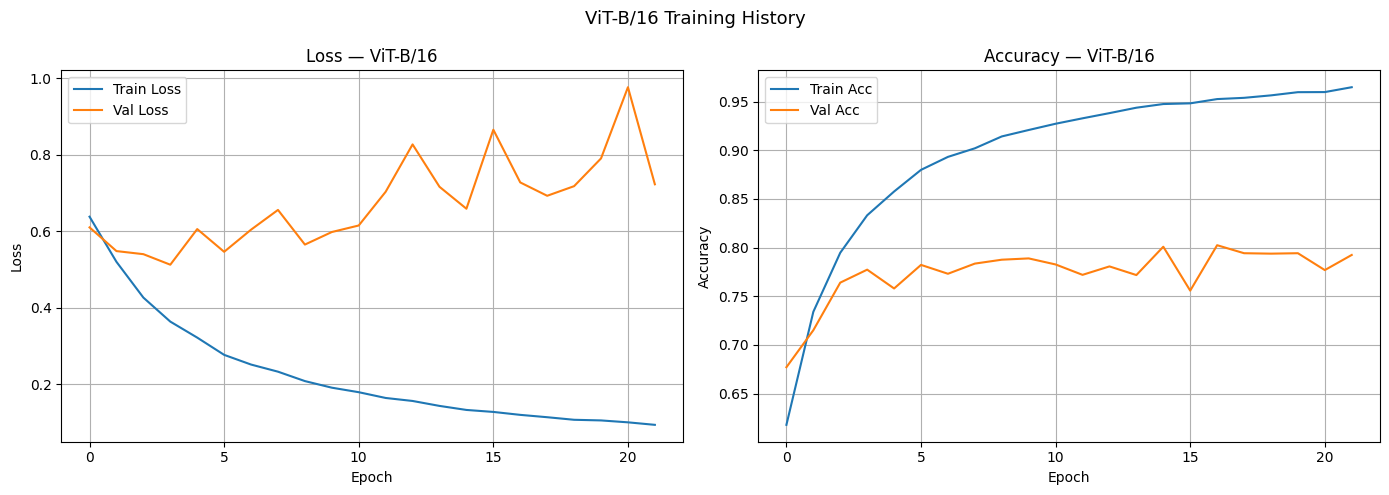


Evaluating ViT-B/16 on test dataset...


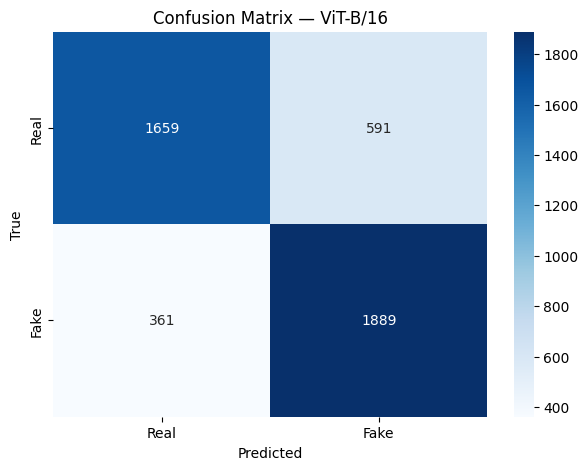


Test Accuracy  (ViT-B/16): 0.7884
Test Precision (ViT-B/16): 0.7617
Test Recall    (ViT-B/16): 0.8396
Test F1-Score  (ViT-B/16): 0.7987


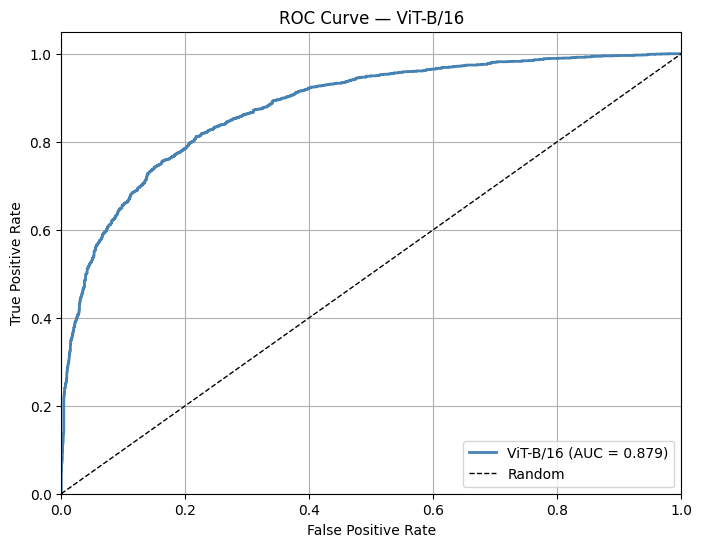

AUC (ViT-B/16): 0.8787


In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import (confusion_matrix, accuracy_score,
                             precision_score, recall_score,
                             f1_score, roc_curve, auc)
import torch

def to_float(x):
    return x.cpu().item() if isinstance(x, torch.Tensor) else float(x)

hist_vit_b16['train_acc'] = [to_float(a) for a in hist_vit_b16['train_acc']]
hist_vit_b16['val_acc']   = [to_float(a) for a in hist_vit_b16['val_acc']]

# --- Training curves ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(hist_vit_b16['train_loss'], label='Train Loss')
axes[0].plot(hist_vit_b16['val_loss'],   label='Val Loss')
axes[0].set_title('Loss — ViT-B/16')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(True)

axes[1].plot(hist_vit_b16['train_acc'], label='Train Acc')
axes[1].plot(hist_vit_b16['val_acc'],   label='Val Acc')
axes[1].set_title('Accuracy — ViT-B/16')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].legend(); axes[1].grid(True)

plt.suptitle('ViT-B/16 Training History', fontsize=13)
plt.tight_layout(); plt.show()

# --- Test evaluation ---
model_vit_b16_ft.eval()
all_labels_vit_b16, all_preds_vit_b16 = [], []
print("\nEvaluating ViT-B/16 on test dataset...")

with torch.no_grad():
    for inputs, labels in test_loader_vit_b16:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model_vit_b16_ft(inputs)
        _, preds = torch.max(outputs, 1)
        all_labels_vit_b16.extend(labels.cpu().numpy())
        all_preds_vit_b16.extend(preds.cpu().numpy())

all_labels_vit_b16 = np.array(all_labels_vit_b16)
all_preds_vit_b16  = np.array(all_preds_vit_b16)

# Confusion matrix
cm_vit_b16 = confusion_matrix(all_labels_vit_b16, all_preds_vit_b16)
plt.figure(figsize=(7, 5))
sns.heatmap(cm_vit_b16, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Real', 'Fake'],
            yticklabels=['Real', 'Fake'])
plt.xlabel('Predicted'); plt.ylabel('True')
plt.title('Confusion Matrix — ViT-B/16'); plt.show()

# Scalar metrics
accuracy_vit_b16  = accuracy_score(all_labels_vit_b16, all_preds_vit_b16)
precision_vit_b16 = precision_score(all_labels_vit_b16, all_preds_vit_b16, average='binary')
recall_vit_b16    = recall_score(all_labels_vit_b16, all_preds_vit_b16, average='binary')
f1_vit_b16        = f1_score(all_labels_vit_b16, all_preds_vit_b16, average='binary')

print(f"\nTest Accuracy  (ViT-B/16): {accuracy_vit_b16:.4f}")
print(f"Test Precision (ViT-B/16): {precision_vit_b16:.4f}")
print(f"Test Recall    (ViT-B/16): {recall_vit_b16:.4f}")
print(f"Test F1-Score  (ViT-B/16): {f1_vit_b16:.4f}")

# ROC curve
all_labels_roc_vit_b16, all_probs_roc_vit_b16 = [], []
with torch.no_grad():
    for inputs, labels in test_loader_vit_b16:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model_vit_b16_ft(inputs)
        probs = torch.softmax(outputs, dim=1)
        all_labels_roc_vit_b16.extend(labels.cpu().numpy())
        all_probs_roc_vit_b16.extend(probs[:, 1].cpu().numpy())

fpr_vit_b16, tpr_vit_b16, _ = roc_curve(all_labels_roc_vit_b16, all_probs_roc_vit_b16)
roc_auc_vit_b16 = auc(fpr_vit_b16, tpr_vit_b16)

plt.figure(figsize=(8, 6))
plt.plot(fpr_vit_b16, tpr_vit_b16, color='steelblue', lw=2,
         label=f'ViT-B/16 (AUC = {roc_auc_vit_b16:.3f})')
plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random')
plt.xlim([0, 1]); plt.ylim([0, 1.05])
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curve — ViT-B/16')
plt.legend(loc='lower right'); plt.grid(True); plt.show()
print(f"AUC (ViT-B/16): {roc_auc_vit_b16:.4f}")


# Vision Transformer — ViT-B/32 (Baseline Model 2)

In [15]:
# ============================================================
# ViT-B/32  DATA LOADERS
# patch_size=32 → same 224×224 input, larger patches
# Reuses train_transform_vit / val_test_transform_vit from above
# ============================================================

train_dataset_vit_b32 = DeepfakeDataset(train_fake, train_real,
                                         transform=train_transform_vit)
val_dataset_vit_b32   = DeepfakeDataset(validation_fake, validation_real,
                                         transform=val_test_transform_vit)
test_dataset_vit_b32  = DeepfakeDataset(test_fake, test_real,
                                         transform=val_test_transform_vit)

train_loader_vit_b32 = DataLoader(train_dataset_vit_b32, batch_size=BATCH_SIZE,
                                   shuffle=True,  num_workers=2)
val_loader_vit_b32   = DataLoader(val_dataset_vit_b32,   batch_size=BATCH_SIZE,
                                   shuffle=False, num_workers=2)
test_loader_vit_b32  = DataLoader(test_dataset_vit_b32,  batch_size=BATCH_SIZE,
                                   shuffle=False, num_workers=2)

print("ViT-B/32 loaders ready (224×224, patch_size=32).")


ViT-B/32 loaders ready (224×224, patch_size=32).


In [16]:
import torchvision.models as models
import torch.nn as nn
import torch.optim as optim

# ============================================================
# ViT-B/32 MODEL SETUP
# patch_size=32, hidden_dim=768, heads=12, layers=12
# Fewer, larger patches → faster; slightly lower accuracy than B/16
# ============================================================

model_vit_b32 = models.vit_b_32(
    weights=models.ViT_B_32_Weights.DEFAULT
)

# Freeze entire backbone
for param in model_vit_b32.parameters():
    param.requires_grad = False

print("All ViT-B/32 layers frozen.")

# Unfreeze last 3 encoder blocks
for block in model_vit_b32.encoder.layers[-3:]:
    for param in block.parameters():
        param.requires_grad = True

print("Last 3 transformer encoder blocks unfrozen.")

# Replace classification head
in_features_vit_b32 = model_vit_b32.heads.head.in_features

model_vit_b32.heads = nn.Sequential(
    nn.LayerNorm(in_features_vit_b32),
    nn.Linear(in_features_vit_b32, 512),
    nn.GELU(),
    nn.Dropout(0.3),
    nn.Linear(512, 128),
    nn.GELU(),
    nn.Dropout(0.2),
    nn.Linear(128, 2)
)

print(f"Custom head attached (in_features={in_features_vit_b32}).")

criterion_vit_b32 = nn.CrossEntropyLoss()
optimizer_vit_b32 = optim.AdamW(
    filter(lambda p: p.requires_grad, model_vit_b32.parameters()),
    lr=1e-4, weight_decay=0.01
)

model_vit_b32 = model_vit_b32.to(device)
print(f"ViT-B/32 moved to: {device}")

trainable = sum(p.numel() for p in model_vit_b32.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model_vit_b32.parameters())
print(f"Trainable params: {trainable:,} / {total:,} ({100*trainable/total:.1f}%)")


Downloading: "https://download.pytorch.org/models/vit_b_32-d86f8d99.pth" to /root/.cache/torch/hub/checkpoints/vit_b_32-d86f8d99.pth


100%|██████████| 337M/337M [00:01<00:00, 230MB/s]  


All ViT-B/32 layers frozen.
Last 3 transformer encoder blocks unfrozen.
Custom head attached (in_features=768).
ViT-B/32 moved to: cuda:0
Trainable params: 21,724,802 / 87,916,418 (24.7%)


In [17]:
print("\n--- Starting ViT-B/32 Training ---")

model_vit_b32_ft, hist_vit_b32 = train_model(
    model_vit_b32,
    criterion_vit_b32,
    optimizer_vit_b32,
    train_loader_vit_b32,
    val_loader_vit_b32,
    num_epochs=30,
    patience=5,
    save_path="best_vit_b32.pth"
)

print("\nTraining complete for ViT-B/32.")
print("Best model saved to: best_vit_b32.pth")



--- Starting ViT-B/32 Training ---
Epoch 1/30
----------
train Loss: 0.6522 Acc: 0.5992
val Loss: 0.6369 Acc: 0.6413
Best model saved.
Epoch 2/30
----------
train Loss: 0.5656 Acc: 0.6983
val Loss: 0.6368 Acc: 0.6280
Epoch 3/30
----------
train Loss: 0.5020 Acc: 0.7524
val Loss: 0.6176 Acc: 0.7109
Best model saved.
Epoch 4/30
----------
train Loss: 0.4322 Acc: 0.7928
val Loss: 0.7335 Acc: 0.6740
Epoch 5/30
----------
train Loss: 0.3856 Acc: 0.8243
val Loss: 0.6394 Acc: 0.7140
Best model saved.
Epoch 6/30
----------
train Loss: 0.3448 Acc: 0.8463
val Loss: 0.6528 Acc: 0.7273
Best model saved.
Epoch 7/30
----------
train Loss: 0.3111 Acc: 0.8642
val Loss: 0.6962 Acc: 0.7367
Best model saved.
Epoch 8/30
----------
train Loss: 0.2933 Acc: 0.8698
val Loss: 0.6773 Acc: 0.7293
Epoch 9/30
----------
train Loss: 0.2561 Acc: 0.8905
val Loss: 0.6630 Acc: 0.7373
Best model saved.
Epoch 10/30
----------
train Loss: 0.2407 Acc: 0.8980
val Loss: 0.6256 Acc: 0.7442
Best model saved.
Epoch 11/30
-----

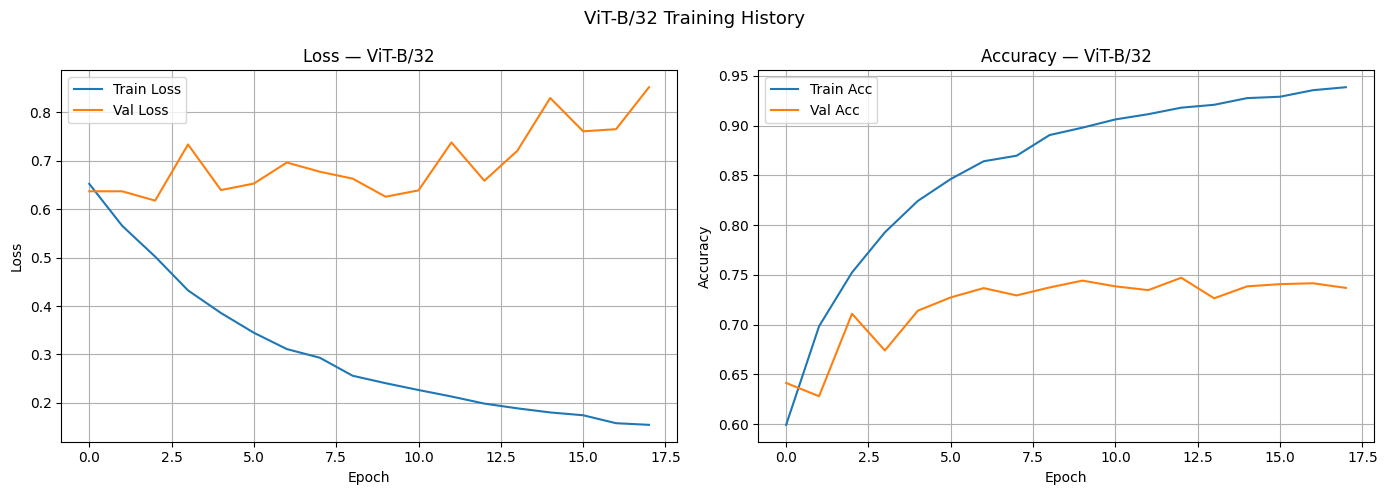


Evaluating ViT-B/32 on test dataset...


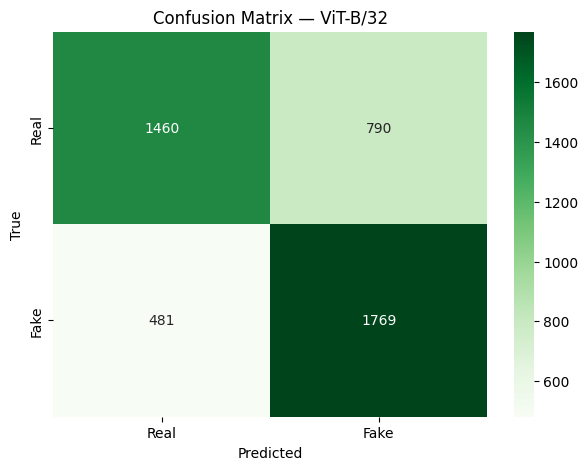


Test Accuracy  (ViT-B/32): 0.7176
Test Precision (ViT-B/32): 0.6913
Test Recall    (ViT-B/32): 0.7862
Test F1-Score  (ViT-B/32): 0.7357


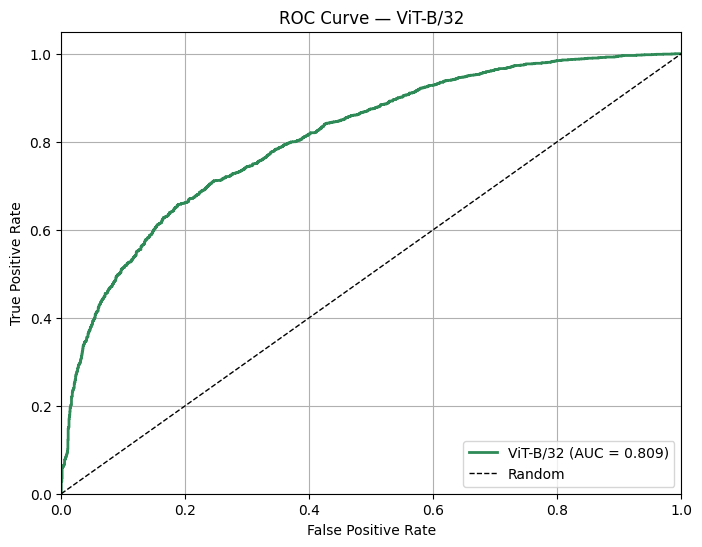

AUC (ViT-B/32): 0.8093


In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import (confusion_matrix, accuracy_score,
                             precision_score, recall_score,
                             f1_score, roc_curve, auc)
import torch

hist_vit_b32['train_acc'] = [to_float(a) for a in hist_vit_b32['train_acc']]
hist_vit_b32['val_acc']   = [to_float(a) for a in hist_vit_b32['val_acc']]

# Training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(hist_vit_b32['train_loss'], label='Train Loss')
axes[0].plot(hist_vit_b32['val_loss'],   label='Val Loss')
axes[0].set_title('Loss — ViT-B/32')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(True)

axes[1].plot(hist_vit_b32['train_acc'], label='Train Acc')
axes[1].plot(hist_vit_b32['val_acc'],   label='Val Acc')
axes[1].set_title('Accuracy — ViT-B/32')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].legend(); axes[1].grid(True)

plt.suptitle('ViT-B/32 Training History', fontsize=13)
plt.tight_layout(); plt.show()

# Test evaluation
model_vit_b32_ft.eval()
all_labels_vit_b32, all_preds_vit_b32 = [], []
print("\nEvaluating ViT-B/32 on test dataset...")

with torch.no_grad():
    for inputs, labels in test_loader_vit_b32:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model_vit_b32_ft(inputs)
        _, preds = torch.max(outputs, 1)
        all_labels_vit_b32.extend(labels.cpu().numpy())
        all_preds_vit_b32.extend(preds.cpu().numpy())

all_labels_vit_b32 = np.array(all_labels_vit_b32)
all_preds_vit_b32  = np.array(all_preds_vit_b32)

cm_vit_b32 = confusion_matrix(all_labels_vit_b32, all_preds_vit_b32)
plt.figure(figsize=(7, 5))
sns.heatmap(cm_vit_b32, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Real', 'Fake'], yticklabels=['Real', 'Fake'])
plt.xlabel('Predicted'); plt.ylabel('True')
plt.title('Confusion Matrix — ViT-B/32'); plt.show()

accuracy_vit_b32  = accuracy_score(all_labels_vit_b32, all_preds_vit_b32)
precision_vit_b32 = precision_score(all_labels_vit_b32, all_preds_vit_b32, average='binary')
recall_vit_b32    = recall_score(all_labels_vit_b32, all_preds_vit_b32, average='binary')
f1_vit_b32        = f1_score(all_labels_vit_b32, all_preds_vit_b32, average='binary')

print(f"\nTest Accuracy  (ViT-B/32): {accuracy_vit_b32:.4f}")
print(f"Test Precision (ViT-B/32): {precision_vit_b32:.4f}")
print(f"Test Recall    (ViT-B/32): {recall_vit_b32:.4f}")
print(f"Test F1-Score  (ViT-B/32): {f1_vit_b32:.4f}")

all_labels_roc_vit_b32, all_probs_roc_vit_b32 = [], []
with torch.no_grad():
    for inputs, labels in test_loader_vit_b32:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model_vit_b32_ft(inputs)
        probs = torch.softmax(outputs, dim=1)
        all_labels_roc_vit_b32.extend(labels.cpu().numpy())
        all_probs_roc_vit_b32.extend(probs[:, 1].cpu().numpy())

fpr_vit_b32, tpr_vit_b32, _ = roc_curve(all_labels_roc_vit_b32, all_probs_roc_vit_b32)
roc_auc_vit_b32 = auc(fpr_vit_b32, tpr_vit_b32)

plt.figure(figsize=(8, 6))
plt.plot(fpr_vit_b32, tpr_vit_b32, color='seagreen', lw=2,
         label=f'ViT-B/32 (AUC = {roc_auc_vit_b32:.3f})')
plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random')
plt.xlim([0, 1]); plt.ylim([0, 1.05])
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curve — ViT-B/32')
plt.legend(loc='lower right'); plt.grid(True); plt.show()
print(f"AUC (ViT-B/32): {roc_auc_vit_b32:.4f}")


In [ ]:
# dumping all training + eval data so i can redo plots later
# both vit-b16 and vit-b32 in one go

import json
import numpy as np

data_to_save = {}

# --- vit-b16 training history ---
data_to_save["hist_vit_b16"] = {
    "train_loss" : hist_vit_b16["train_loss"],
    "val_loss"   : hist_vit_b16["val_loss"],
    "train_acc"  : [float(v) for v in hist_vit_b16["train_acc"]],
    "val_acc"    : [float(v) for v in hist_vit_b16["val_acc"]],
}

# --- vit-b32 training history ---
data_to_save["hist_vit_b32"] = {
    "train_loss" : hist_vit_b32["train_loss"],
    "val_loss"   : hist_vit_b32["val_loss"],
    "train_acc"  : [float(v) for v in hist_vit_b32["train_acc"]],
    "val_acc"    : [float(v) for v in hist_vit_b32["val_acc"]],
}

# predictions + roc for vit-b16
data_to_save["vit_b16_eval"] = {
    "labels" : all_labels_vit_b16.tolist(),
    "preds"  : all_preds_vit_b16.tolist(),
    "fpr"    : fpr_vit_b16.tolist(),
    "tpr"    : tpr_vit_b16.tolist(),
    "auc"    : float(roc_auc_vit_b16),
    "probs"  : all_probs_roc_vit_b16,
}

# predictions + roc for vit-b32
data_to_save["vit_b32_eval"] = {
    "labels" : all_labels_vit_b32.tolist(),
    "preds"  : all_preds_vit_b32.tolist(),
    "fpr"    : fpr_vit_b32.tolist(),
    "tpr"    : tpr_vit_b32.tolist(),
    "auc"    : float(roc_auc_vit_b32),
    "probs"  : all_probs_roc_vit_b32,
}

print(json.dumps(data_to_save, indent=2))

# -------------------------------------------------------
# to reproduce graphs later paste the output above and do:
#
#   d = json.loads(raw)
#   hist_vit_b16  = d["hist_vit_b16"]
#   hist_vit_b32  = d["hist_vit_b32"]
#   vit_b16_eval  = d["vit_b16_eval"]
#   vit_b32_eval  = d["vit_b32_eval"]
#
# then just run the plotting cells normally
# -------------------------------------------------------
